In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler



In [95]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 30)

# Load Raw Data

In [96]:
df = pd.read_csv("spotify_tracks.csv")
df.head()

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
0,2r0ROhr7pRN4MXDMT1fEmd,"Leo Das Entry (From ""Leo"")",Anirudh Ravichander,2024,59,https://i.scdn.co/image/ab...,"Leo Das Entry (From ""Leo"")",0.0241,0.753,97297,0.970,0.055300,8,0.1000,-5.994,0,0.1030,110.997,4,0.459,https://open.spotify.com/t...,Tamil
1,4I38e6Dg52a2o2a8i5Q5PW,AAO KILLELLE,"Anirudh Ravichander, Pravi...",2024,47,https://i.scdn.co/image/ab...,AAO KILLELLE,0.0851,0.780,207369,0.793,0.000000,10,0.0951,-5.674,0,0.0952,164.995,3,0.821,https://open.spotify.com/t...,Tamil
2,59NoiRhnom3lTeRFaBzOev,Mayakiriye Sirikiriye - Or...,"Anirudh Ravichander, Anive...",2024,35,https://i.scdn.co/image/ab...,Mayakiriye Sirikiriye (Orc...,0.0311,0.457,82551,0.491,0.000000,2,0.0831,-8.937,0,0.1530,169.996,4,0.598,https://open.spotify.com/t...,Tamil
3,5uUqRQd385pvLxC8JX3tXn,Scene Ah Scene Ah - Experi...,"Anirudh Ravichander, Bhara...",2024,24,https://i.scdn.co/image/ab...,Scene Ah Scene Ah (Experim...,0.2270,0.718,115831,0.630,0.000727,7,0.1240,-11.104,1,0.4450,169.996,4,0.362,https://open.spotify.com/t...,Tamil
4,1KaBRg2xgNeCljmyxBH1mo,Gundellonaa X I Am A Disco...,"Anirudh Ravichander, Benny...",2024,22,https://i.scdn.co/image/ab...,Gundellonaa X I Am a Disco...,0.0153,0.689,129621,0.748,0.000001,7,0.3450,-9.637,1,0.1580,128.961,4,0.593,https://open.spotify.com/t...,Tamil


In [97]:
df.shape

(62317, 22)

In [98]:
df.isnull().sum()

track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64

# Remove Unnecessary Columns

In [99]:
df1 = df.drop(['track_id','artwork_url','track_url'],axis = 'columns')
df1.shape

(62317, 19)

In [100]:
df1.columns

Index(['track_name', 'artist_name', 'year', 'popularity', 'album_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence', 'language'],
      dtype='str')

# Select Audio Features for Recommendation

In [101]:
features = ['acousticness', 'danceability','energy','instrumentalness','liveness','loudness','speechiness','valence','tempo']
X = df1[features]
X.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
0,0.0241,0.753,0.970,0.055300,0.1000,-5.994,0.1030,0.459,110.997
1,0.0851,0.780,0.793,0.000000,0.0951,-5.674,0.0952,0.821,164.995
2,0.0311,0.457,0.491,0.000000,0.0831,-8.937,0.1530,0.598,169.996
3,0.2270,0.718,0.630,0.000727,0.1240,-11.104,0.4450,0.362,169.996
4,0.0153,0.689,0.748,0.000001,0.3450,-9.637,0.1580,0.593,128.961


In [102]:
X.describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
count,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000
mean,0.362292,0.596807,0.602496,0.146215,0.194143,-65.103433,0.087722,0.495226,117.931247
std,0.314609,0.186209,0.246144,0.307804,0.172030,2369.051478,0.115150,0.264787,28.509459
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-100000.000000,-1.000000,-1.000000,-1.000000
25%,0.067100,0.497000,0.440000,0.000000,0.093200,-10.727000,0.036700,0.292000,95.942000
50%,0.286000,0.631000,0.639000,0.000025,0.125000,-7.506000,0.048900,0.507000,117.991000
75%,0.632000,0.730000,0.803000,0.015200,0.243000,-5.456000,0.089100,0.710000,135.081000
max,0.996000,0.986000,1.000000,0.999000,0.998000,1.233000,0.959000,0.995000,239.970000


# Identify Invalid Values
# -1 and -100000 represent invalid/missing values in the dataset
# These values can distort similarity calculations

In [103]:
for col in X:
    print(col, (X[col] == -1).sum()) # Number of columns that have -1

acousticness 35
danceability 35
energy 35
instrumentalness 35
liveness 35
loudness 0
speechiness 35
valence 35
tempo 35


In [104]:
(X['loudness'] == -100000).sum() # Number of columns that have -100000 in Loudness

np.int64(35)

In [105]:
X.isnull().sum()

acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
valence             0
tempo               0
dtype: int64

In [106]:
X.shape

(62317, 9)

# Identify Rows Containing invalid Values

In [107]:
invalid_rows = (
    (X == -1).any(axis=1) |
    (X['loudness'] == -100000)
)

invalid_rows.sum()

np.int64(35)

# Remove the Invalid Rows from the Dataset

In [108]:
X_clean = X[~invalid_rows].copy()
X_clean = X_clean.reset_index(drop=True)
X_clean.shape

(62282, 9)

In [109]:
X_clean.describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
count,62282.000000,62282.000000,62282.000000,62282.000000,62282.000000,62282.000000,62282.000000,62282.000000,62282.000000
mean,0.363057,0.597704,0.603397,0.146859,0.194814,-8.944006,0.088333,0.496066,117.998081
std,0.313035,0.182372,0.243264,0.306688,0.169733,5.330622,0.112257,0.262477,28.377679
min,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000
25%,0.067300,0.498000,0.440000,0.000000,0.093200,-10.719750,0.036700,0.293000,95.953000
50%,0.286000,0.631000,0.639000,0.000025,0.125000,-7.505000,0.048900,0.508000,117.997000
75%,0.633000,0.730000,0.803000,0.015200,0.243000,-5.455000,0.089200,0.710000,135.090000
max,0.996000,0.986000,1.000000,0.999000,0.998000,1.233000,0.959000,0.995000,239.970000


In [110]:
X_clean.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
0,0.0241,0.753,0.970,0.055300,0.1000,-5.994,0.1030,0.459,110.997
1,0.0851,0.780,0.793,0.000000,0.0951,-5.674,0.0952,0.821,164.995
2,0.0311,0.457,0.491,0.000000,0.0831,-8.937,0.1530,0.598,169.996
3,0.2270,0.718,0.630,0.000727,0.1240,-11.104,0.4450,0.362,169.996
4,0.0153,0.689,0.748,0.000001,0.3450,-9.637,0.1580,0.593,128.961


# Verify That Invalid Values Have Been Removed

In [111]:
for x in X_clean:
    print(x, (X_clean[x] == -1).sum())

acousticness 0
danceability 0
energy 0
instrumentalness 0
liveness 0
loudness 0
speechiness 0
valence 0
tempo 0


In [112]:
(X_clean['loudness'] == -100000).sum()

np.int64(0)

# Danceability, Instrumentalness, Tempo Histograms

Text(0.5, 1.0, 'Danceability')

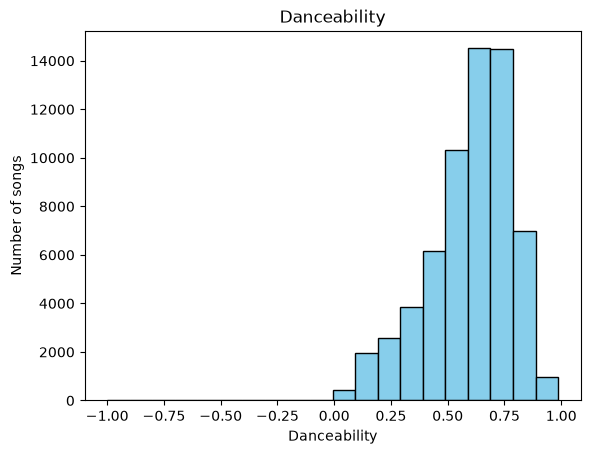

In [113]:
plt.hist(X['danceability'], bins = 20, color = 'skyblue', edgecolor = 'black')
plt.xlabel("Danceability")
plt.ylabel("Number of songs")
plt.title("Danceability")

Text(0.5, 1.0, 'Instrumentalness')

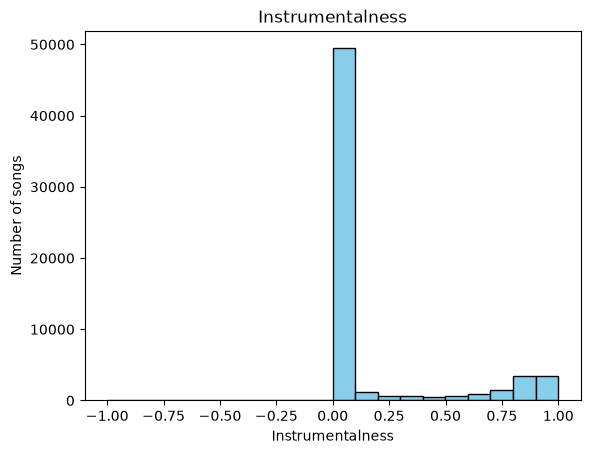

In [114]:
plt.hist(X['instrumentalness'], bins = 20, color = 'skyblue', edgecolor = 'black')
plt.xlabel("Instrumentalness")
plt.ylabel("Number of songs")
plt.title("Instrumentalness")


Text(0.5, 1.0, 'Tempo')

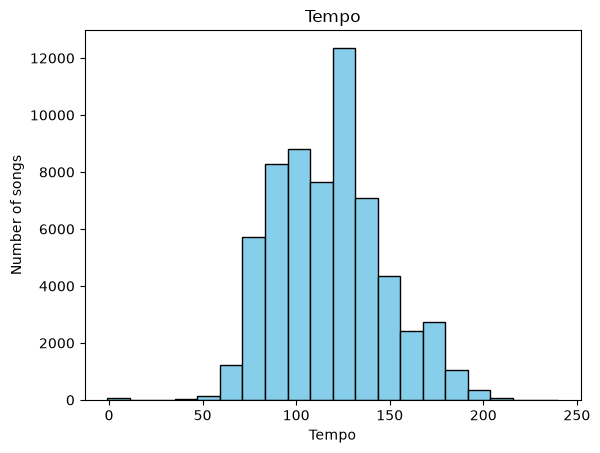

In [115]:
plt.hist(X['tempo'], bins = 20, color = 'skyblue', edgecolor = 'black')
plt.xlabel("Tempo")
plt.ylabel("Number of songs")
plt.title("Tempo")


# Correlation between music features


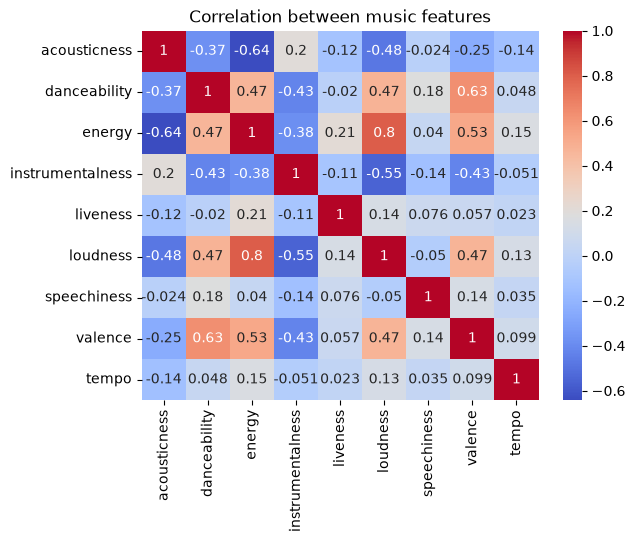

In [116]:
corr = X_clean.corr()

sns.heatmap(corr, annot= True, cmap = 'coolwarm')
plt.title("Correlation between music features")
plt.show()

# Standardize Audio Features
# Standardization puts all features on a comparable scale

In [117]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_clean)
scaled_X = pd.DataFrame(scaled_data,columns = features)
scaled_X.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
0,-1.082817,0.851542,1.507031,-0.298542,-0.558609,0.553412,0.130654,-0.141219,-0.246713
1,-0.887949,0.999593,0.779420,-0.478857,-0.587478,0.613443,0.061171,1.237958,1.656136
2,-1.060455,-0.771530,-0.462041,-0.478857,-0.658178,0.001314,0.576064,0.388355,1.832367
3,-0.434642,0.659625,0.109360,-0.476487,-0.417209,-0.405208,3.177256,-0.510777,1.832367
4,-1.110929,0.500608,0.594434,-0.478853,0.884846,-0.130003,0.620605,0.369305,0.386325


In [118]:
scaled_X.shape

(62282, 9)

# Create a Cleaned Dataset for Recommendations


In [119]:
df_cleaned = df1[~invalid_rows].copy()
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned.shape

(62282, 19)

In [120]:
df_cleaned.head()

,track_name,artist_name,year,popularity,album_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,language
0,"Leo Das Entry (From ""Leo"")",Anirudh Ravichander,2024,59,"Leo Das Entry (From ""Leo"")",0.0241,0.753,97297,0.970,0.055300,8,0.1000,-5.994,0,0.1030,110.997,4,0.459,Tamil
1,AAO KILLELLE,"Anirudh Ravichander, Pravi...",2024,47,AAO KILLELLE,0.0851,0.780,207369,0.793,0.000000,10,0.0951,-5.674,0,0.0952,164.995,3,0.821,Tamil
2,Mayakiriye Sirikiriye - Or...,"Anirudh Ravichander, Anive...",2024,35,Mayakiriye Sirikiriye (Orc...,0.0311,0.457,82551,0.491,0.000000,2,0.0831,-8.937,0,0.1530,169.996,4,0.598,Tamil
3,Scene Ah Scene Ah - Experi...,"Anirudh Ravichander, Bhara...",2024,24,Scene Ah Scene Ah (Experim...,0.2270,0.718,115831,0.630,0.000727,7,0.1240,-11.104,1,0.4450,169.996,4,0.362,Tamil
4,Gundellonaa X I Am A Disco...,"Anirudh Ravichander, Benny...",2024,22,Gundellonaa X I Am a Disco...,0.0153,0.689,129621,0.748,0.000001,7,0.3450,-9.637,1,0.1580,128.961,4,0.593,Tamil


# Function to find a song in the dataset

In [121]:
def find_song(song_name):

    # First, look for an exact match
    song = df_cleaned[
        df_cleaned['track_name'].str.lower() == song_name.lower()
    ]
    song = song.drop_duplicates(
    subset=['track_name', 'artist_name']
)

    # If no exact match, look for a partial match
    if song.empty:
        song = df_cleaned[
            df_cleaned['track_name'].str.lower().str.contains(
                song_name.lower(),
                na=False
            )
        ]

    # If no match at all
    if song.empty:
        print("\nSorry, that song is not in the dataset.")
        return None, None, None

		# If Multiple songs Found
    if len(song) > 1:
        print("\nMultiple Songs Found")

		# Display Choices
        for number, (index, row) in enumerate(song.iterrows(), start = 1):
            print(number, "-", row['track_name'], row['artist_name'])

		# Ask user to choose the song
        try:
            choice = int(input("\nChoose a song :"))
        except ValueError:
            print("\nPlease enter a number.")
            return None, None, None
      
		# Get selected song
        selected_song = song.iloc[choice - 1]
        song_index = selected_song.name
        actual_songname = selected_song['track_name']
        artist_name = selected_song['artist_name']
        return song_index, actual_songname, artist_name
				
    # If only one song was found
    song_index = song.index[0]
    actual_songname = song.iloc[0]['track_name']
    artist_name = song.iloc[0]['artist_name']
    
    return song_index, actual_songname, artist_name

In [122]:
scaled_X.isna().sum()

acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
valence             0
tempo               0
dtype: int64

# Song Recommendation Function


In [123]:
def recommend_songs(song_name, song_language, number_of_songs):

    # Find the song
    song_index, actual_songname, artist_name = find_song(song_name)

    # Stop if the song was not found
    if song_index is None:
        return pd.DataFrame()

    # Print the selected song
    print("\nSelected song:")
    print("Song name : ", actual_songname)
    print("Artist name : ", artist_name)
    print("Language : ", song_language)

    # Calculate cosine similarity
    cosine = cosine_similarity(
        scaled_X.iloc[[song_index]],
        scaled_X
    )

    cosine = cosine.squeeze()

    # Add similarity scores to the dataset
    df_cleaned['Similarity'] = cosine

    # Filter by preferred language
    recommendations = df_cleaned[
        df_cleaned['language'].str.lower() == song_language.lower()
    ].copy()

    # Sort by similarity
    recommendations = recommendations.sort_values(
        by='Similarity',
        ascending=False
    )

    # Remove duplicate songs
    # Same song + same artist = duplicate
    recommendations = recommendations.drop_duplicates(
        subset=['track_name', 'artist_name']
    )
    # Don't Recommend the song itself
    recommendations = recommendations[recommendations['track_name'] != actual_songname]

    # Take requested number of songs
    recommendations = recommendations.head(number_of_songs)

    # Convert similarity to percentage
    recommendations['Similarity'] = (
        recommendations['Similarity'] * 100
    ).round(2)

    # Rename column
    recommendations = recommendations.rename(
        columns={'Similarity': 'Similarity (%)'}
    )

    # Select columns to display
    recommendations = recommendations[
        [
            'track_name',
            'artist_name',
            'language',
            'Similarity (%)'
        ]
    ]

    return recommendations

In [124]:
while True:

    song_name = input("Enter a song: ").strip()

    song_language = input(
        "Enter your preferred language for recommendation : "
    ).strip()

    try:

        # Check if song is empty
        if not song_name:
            raise ValueError("Song name cannot be empty")

        # Check if language is empty
        if not song_language:
            raise ValueError("Song language cannot be empty")

        # Check if language exists
        if song_language.lower() not in df_cleaned['language'].str.lower().unique():
            raise ValueError("Language not found")

        # Ask for the number of recommendations
        number_of_songs = int(
            input(
                "Enter the number of recommendations you want : "
            )
        )

        # Check if number of songs exists
        if not number_of_songs:
            raise ValueError(
                "Number of Recommendations cannot be empty"
            )

        # If number is less than or equal to 0
        if number_of_songs <= 0:
            raise ValueError(
                "Number must be greater than 0"
            )

        # If number is more than 50
        if number_of_songs > 50:
            raise ValueError(
                "You can only request maximum of 50 recommendations"
            )

        # Get recommendations
        recommendations = recommend_songs(
            song_name,
            song_language,
            number_of_songs
        )

    except ValueError as e:

        print("Error :", e)

    else:

        if recommendations.empty:

            print("Sorry, no recommendations found.")

        else:

            print("\nRecommended Songs:\n")

            for number, (index, row) in enumerate(
                recommendations.iterrows(),
                start=1
            ):
                print(
                    number,
                    "-",
                    row['track_name'],
                    "-",
                    row['artist_name'],
                    "-",
                    row['language'],
                    "-",
                    row['Similarity (%)']
                )

    # Ask if user wants to search again
    while True:

        again = input(
            "\nWould you like to search again? (y/n)"
        ).strip().lower()

        if again == "y":
            break

        elif again == "n":
            break

        else:
            print("Please enter y or n")

    # Stop the main loop
    if again == "n":

        print("\nThank you for using music recommender!")

        break


Multiple Songs Found
1 - Hosanna A.R. Rahman, Leon D'souza, Suzanne D'Mello
2 - Hosanna A.R. Rahman, Vijay Prakash, Suzanne D'Mello, Blaaze

Selected song:
Song name :  Hosanna
Artist name :  A.R. Rahman, Leon D'souza, Suzanne D'Mello
Language :  hindi

Recommended Songs:

1 - Rasiya (From "Brahmastra") - Pritam, Shreya Ghoshal, TUSHAR JOSHI - Hindi - 95.07
2 - Rasiya - Pritam, Shreya Ghoshal, TUSHAR JOSHI - Hindi - 95.07
3 - Pal Chin - Javed Ali - Hindi - 94.51
4 - Karke Dua (From "Luv Shv Pyar Vyar") - Javed Ali, Gufy - Hindi - 94.22
5 - Karke Dua - Javed Ali - Hindi - 94.22

Thank you for using music recommender!
